##Atividade PROJETO FINAL


Luis Ernani Viniski

Leonardo Barbosa dos Santos

Gabriel Bezerra Carrazzoni

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import statistics as sts
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, single, average, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples


In [ ]:
#Importando os dados
url = "https://raw.githubusercontent.com/Gabrielxbc00/bank_transactions_data_2/refs/heads/main/bank_transactions_data_2.csv "
df = pd.read_csv(url)

In [ ]:
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


In [ ]:
#Informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [ ]:
#Estatísticas do Dataset
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [ ]:
#Verificando se existem linhas duplicadas
df.duplicated().sum()

0

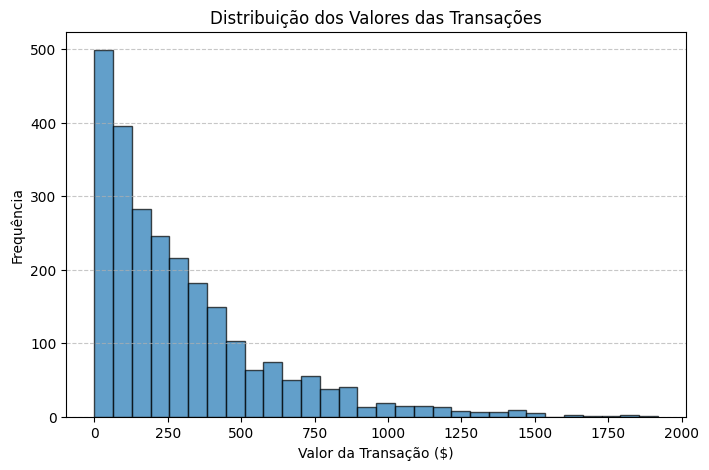

In [ ]:
# Histograma do valor das transações
plt.figure(figsize=(8, 5))
plt.hist(df["TransactionAmount"], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Valor da Transação ($)")
plt.ylabel("Frequência")
plt.title("Distribuição dos Valores das Transações")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

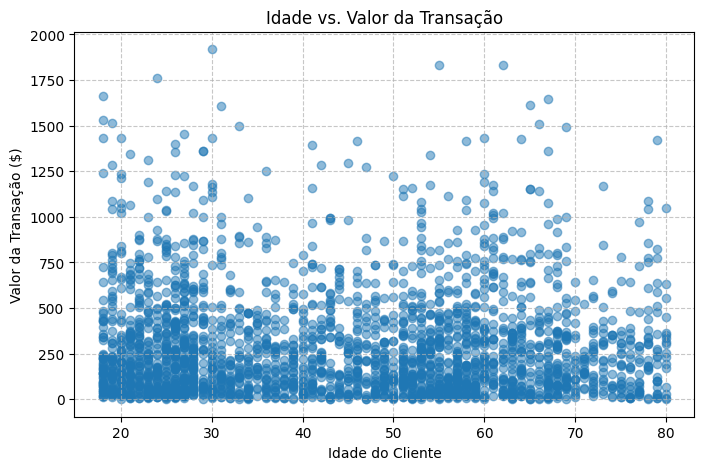

In [ ]:
# Scatter plot: Idade vs. Valor da Transação
plt.figure(figsize=(8, 5))
plt.scatter(df["CustomerAge"], df["TransactionAmount"], alpha=0.5)
plt.xlabel("Idade do Cliente")
plt.ylabel("Valor da Transação ($)")
plt.title("Idade vs. Valor da Transação")
plt.grid(linestyle="--", alpha=0.7)
plt.show()

Insights das visualizações:

Distribuição dos valores das transações:
A maioria das transações ocorre abaixo de $500, mas há algumas transações de alto valor, próximas de $1900.

Distribuição dos saldos das contas:
Existem alguns clientes com saldos muito altos, enquanto a maioria tem valores médios entre $1000 e $8000.

Idade vs. Valor da Transação:
Não há um padrão claro, mas algumas transações de alto valor são feitas por clientes de idade mais avançada.

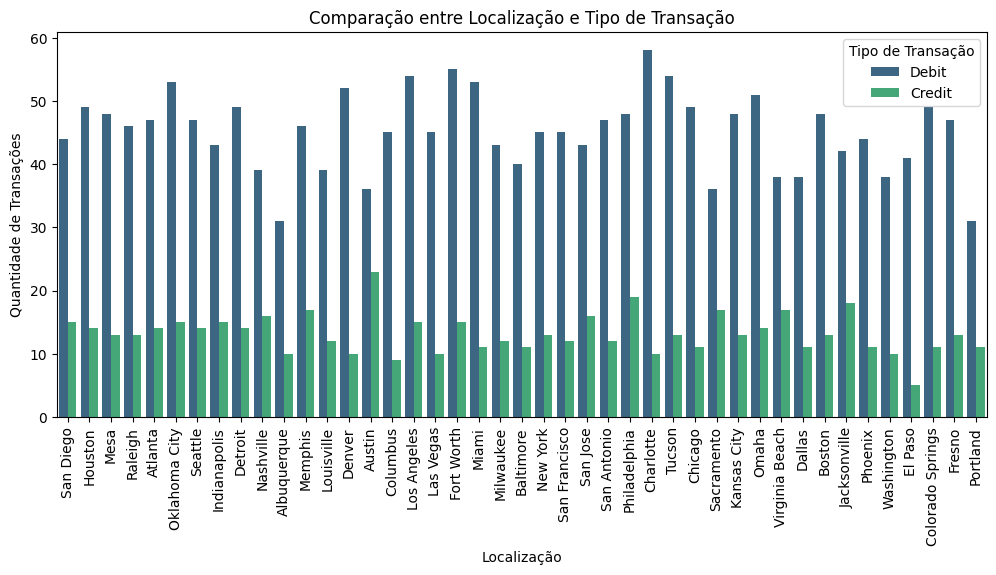

In [ ]:
# Gráfico de comparação entre 'Location' e 'TransactionType'
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Location', hue='TransactionType', palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("Localização")
plt.ylabel("Quantidade de Transações")
plt.title("Comparação entre Localização e Tipo de Transação")
plt.legend(title="Tipo de Transação")
plt.show()

Comparação entre Localização e Tipo de Transação

Observação geral: A maioria das transações realizadas são do tipo débito, independentemente da localização.

Algumas cidades apresentam um número ligeiramente maior de transações do tipo crédito, sugerindo perfis de clientes que utilizam mais esse meio de pagamento.

Possível insight: Diferentes estratégias podem ser adotadas para incentivar o uso de cartões de crédito em locais onde o débito predomina.

<ipython-input-10-f180f96cbdeb>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CustomerOccupation', y='CustomerAge', palette="magma")


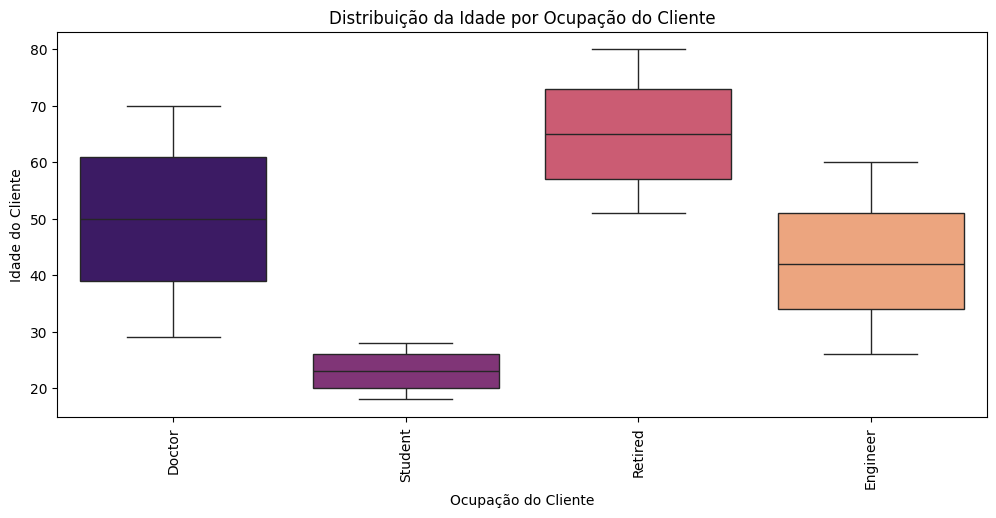

In [ ]:
# Gráfico de comparação entre 'CustomerOccupation' e 'CustomerAge'
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='CustomerOccupation', y='CustomerAge', palette="magma")
plt.xticks(rotation=90)
plt.xlabel("Ocupação do Cliente")
plt.ylabel("Idade do Cliente")
plt.title("Distribuição da Idade por Ocupação do Cliente")
plt.show()

Comparação entre Ocupação e Idade

Estudantes têm idades significativamente mais baixas (faixa etária entre 18 e 25 anos).

Aposentados (Retired) possuem uma faixa etária bem mais alta (entre 50 e 80 anos).

Médicos e Engenheiros possuem uma distribuição de idades mais ampla, mas geralmente estão entre 30 e 60 anos.

Os produtos e serviços financeiros devem ser ajustados conforme a ocupação e a faixa etária do cliente. Estudantes podem precisar de contas com benefícios, enquanto aposentados podem ser mais receptivos a investimentos conservadores.

<ipython-input-11-98e8014badc8>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="CustomerOccupation", y="AccountBalance", ci=None, palette="coolwarm")
<ipython-input-11-98e8014badc8>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="CustomerOccupation", y="AccountBalance", ci=None, palette="coolwarm")


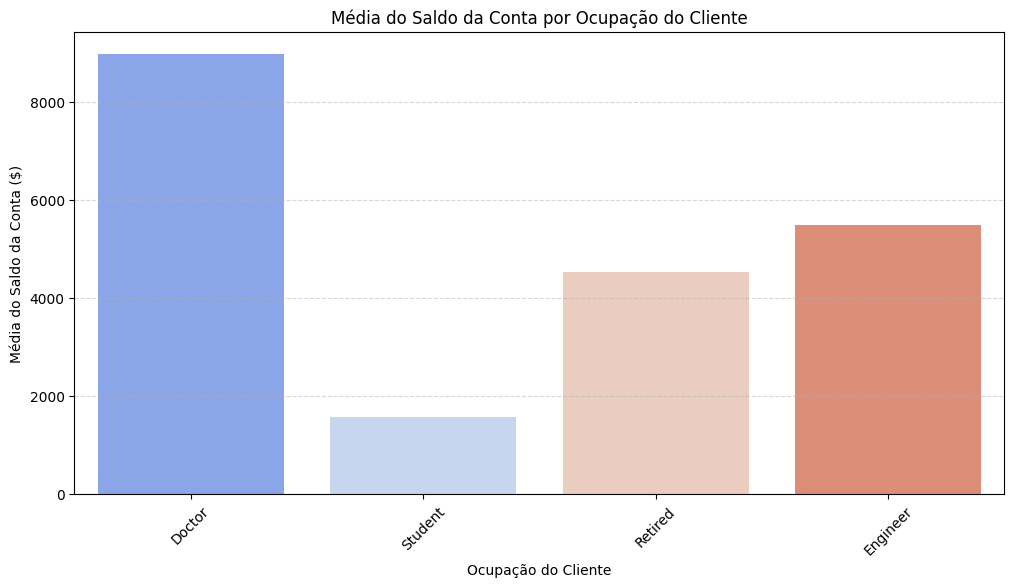

In [ ]:
# Criar um gráfico de barras para comparar a média do saldo da conta por ocupação do cliente
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="CustomerOccupation", y="AccountBalance", ci=None, palette="coolwarm")
plt.xticks(rotation=45)
plt.xlabel("Ocupação do Cliente")
plt.ylabel("Média do Saldo da Conta ($)")
plt.title("Média do Saldo da Conta por Ocupação do Cliente")
plt.grid(axis='y', linestyle="--", alpha=0.5)
plt.show()

Análise do Gráfico: Média do Saldo da Conta por Ocupação

Médicos possuem o maior saldo médio, acima de $9.000, indicando que são clientes financeiramente estáveis e podem ser bons alvos para produtos premium.

Engenheiros aparecem em segundo lugar, com saldo médio em torno de $6.000.

Aposentados possuem um saldo médio próximo de $4.500, o que pode indicar uma abordagem mais conservadora em relação ao dinheiro.

Estudantes têm o menor saldo médio, em torno de $1.500, reforçando a necessidade de produtos bancários acessíveis e incentivos para esse público.

Oportunidades Estratégicas

✅ Ofertas de investimentos e seguros para médicos e engenheiros.

✅ Benefícios para aposentados, como contas sem tarifas e acesso a produtos financeiros seguros.

✅ Incentivos para estudantes, como cashback ou programas de educação financeira.

#Preparando para utilizar o metodo de Silhouette

In [ ]:
# Selecionando variáveis numéricas para clustering
features = df[["TransactionAmount", "CustomerAge", "TransactionDuration", "AccountBalance"]]

# Padronizando os dados para melhor desempenho do K-Means
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

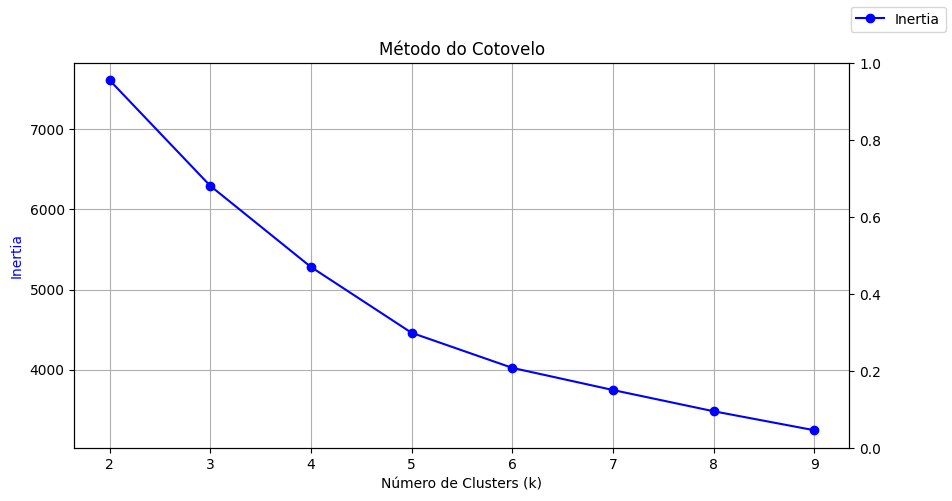

In [ ]:
# Escolhendo o número ideal de clusters usando o método do cotovelo
inertia = []
silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

  # Plotando o método do cotovelo e o coeficiente de Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(k_values, inertia, 'bo-', label='Inertia')

ax1.set_xlabel("Número de Clusters (k)")
ax1.set_ylabel("Inertia", color="blue")
ax1.set_title("Método do Cotovelo")
ax1.grid()

fig.legend(loc="upper right")
plt.show()

A análise do método do cotovelo e do coeficiente de Silhouette indica que um bom número de clusters pode ser 3 ou 4, pois há um ponto de inflexão na inércia e os valores de Silhouette são relativamente altos nesses pontos.

In [ ]:
# Aplicando K-Means com 4 clusters
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_features)

# Estatísticas por cluster
cluster_summary = df.groupby("Cluster")[["TransactionAmount", "CustomerAge", "TransactionDuration", "AccountBalance"]].mean()

# Exibir resumo dos clusters

print(cluster_summary)

         TransactionAmount  CustomerAge  TransactionDuration  AccountBalance
Cluster                                                                     
0               903.349052    46.392157           117.604575     5523.594575
1               206.806503    46.841828           209.091388     5681.281107
2               236.892190    26.958159            97.912134     1686.523877
3               199.571913    56.568478            81.935870     7298.937543


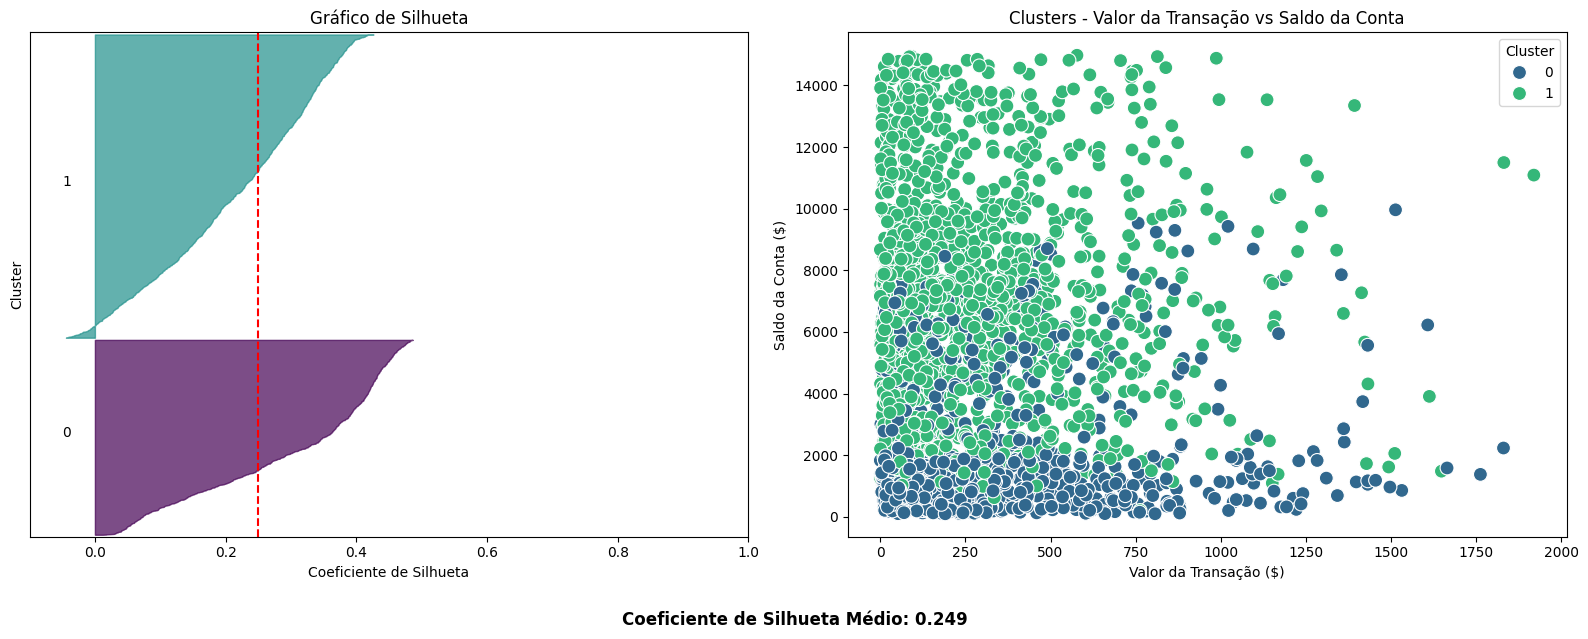

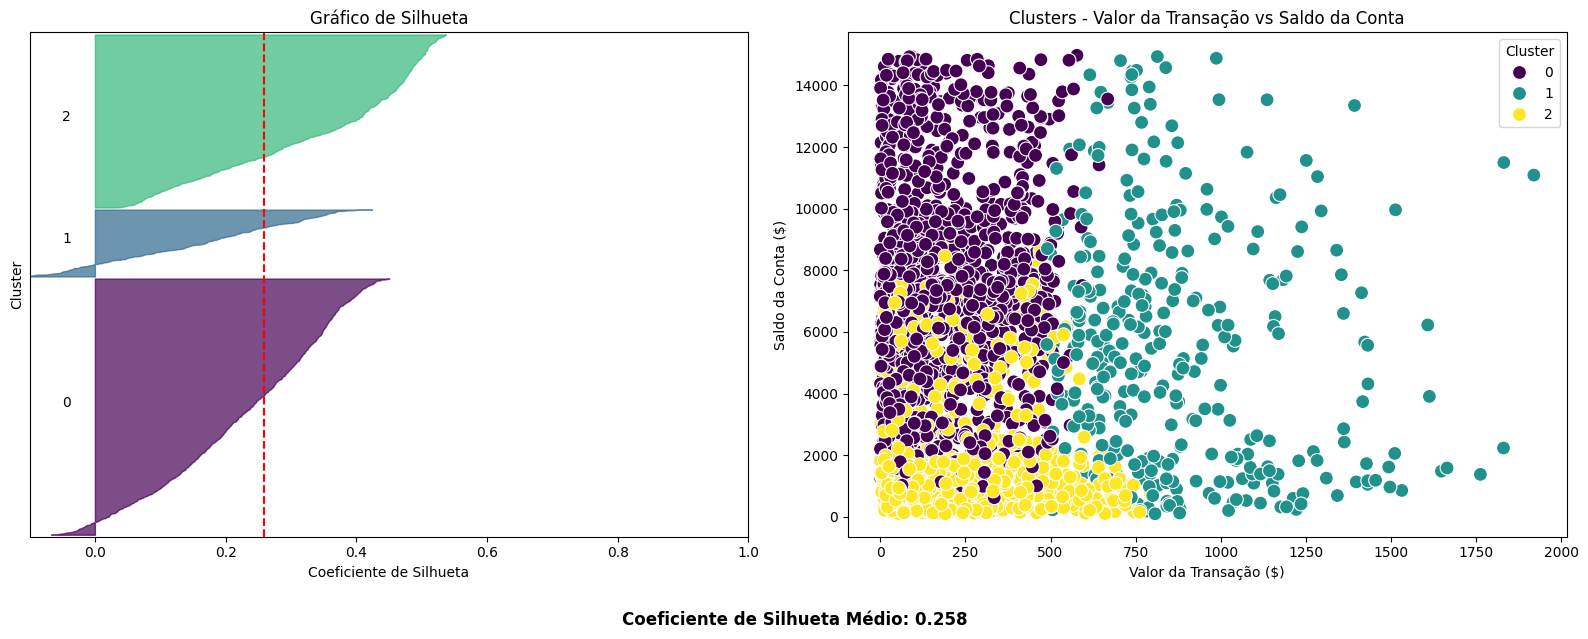

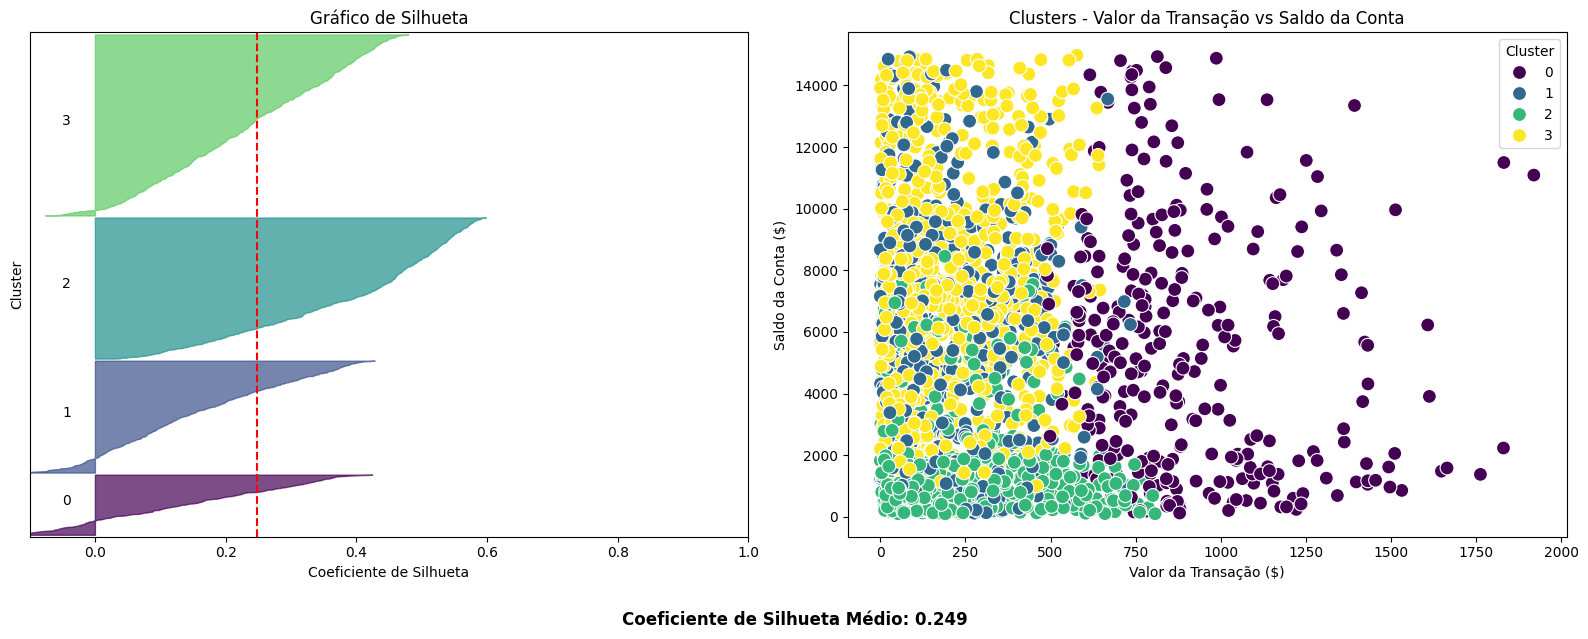

In [ ]:
# Definir o número de clusters
cluster_range = range(2, 5)

for k in cluster_range:
    # Aplicar K-Means
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    df['Cluster'] = kmeans.fit_predict(scaled_features)

    # Calcular métricas de silhueta
    silhouette_avg = silhouette_score(scaled_features, df['Cluster'])
    sample_silhouette_values = silhouette_samples(scaled_features, df['Cluster'])

    # Criar figura com 2 gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ### 1. Gráfico de Silhueta ###
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(scaled_features) + (k + 1) * 10])

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[df['Cluster'] == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.viridis(float(i) / k)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # Adiciona espaço entre os clusters

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title("Gráfico de Silhueta")
    ax1.set_xlabel("Coeficiente de Silhueta")
    ax1.set_ylabel("Cluster")
    ax1.set_yticks([])

    ### 2. Scatterplot dos Clusters ###
    sns.scatterplot(data=df, x='TransactionAmount', y='AccountBalance', hue='Cluster', palette="viridis", s=100, ax=ax2)
    ax2.set_title('Clusters - Valor da Transação vs Saldo da Conta')
    ax2.set_xlabel('Valor da Transação ($)')
    ax2.set_ylabel('Saldo da Conta ($)')
    ax2.legend(title="Cluster")

    fig.text(0.5, -0.05, f"Coeficiente de Silhueta Médio: {silhouette_avg:.3f}", ha="center", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

#Primeiro Conjunto de dados com Média 0.249

1.Gráfico de Silhueta (Esquerda)

Esse gráfico mede a qualidade da clusterização. O coeficiente de Silhueta médio é 0.249, o que indica uma segmentação moderada – longe de ser ruim, mas não extremamente bem definida.

Observamos duas grandes áreas correspondentes aos clusters (0 e 1).
O Cluster 1 apresenta um coeficiente de Silhueta maior que o Cluster 0, sugerindo que seus pontos estão melhor agrupados.

O Cluster 0 tem alguns pontos próximos de zero, indicando que alguns elementos podem estar mal alocados.


2. Scatterplot (Direita) - Valor da Transação vs Saldo da Conta
Cluster 0 (Azul escuro):

Representa clientes com saldos menores e transações de valores variados.
A maioria dos clientes nesse grupo tem transações abaixo de $500.
Essa categoria pode representar clientes com movimentação financeira menor e mais frequente.

Cluster 1 (Verde):

Contém clientes com saldos mais altos e transações de valores mais distribuídos, incluindo valores elevados.

O grupo tem maior dispersão, indicando que clientes de alto saldo podem realizar transações em diferentes faixas de valor.
Conclusões e Insights

Clusters bem definidos:

A divisão em dois grupos principais faz sentido, pois separa clientes com menor capacidade financeira (Cluster 0) dos que possuem um saldo mais elevado (Cluster 1).

Melhoria na clusterização:

Como o coeficiente de Silhueta está próximo de 0.25, uma segmentação com mais clusters (ex: 3 ou 4) poderia ser testada para refinar a separação dos perfis de clientes.

Sugestão para o banco:

Cluster 0: Pode ser foco de estratégias de inclusão financeira, como benefícios em transações e educação financeira.

Cluster 1: Clientes com alto saldo podem ser incentivados a utilizar produtos premium, como investimentos exclusivos e assessoria financeira personalizada.

#Segundo Conjunto de Dados com Média 0.258
1.Gráfico de Silhueta (Esquerda)

O coeficiente de Silhueta médio aumentou para 0.258, o que indica uma leve melhora na separação dos clusters em relação à análise anterior (0.249).

Cluster 0 (Roxo): Possui maior dispersão de valores, com alguns pontos próximos de zero, indicando clientes que não estão claramente agrupados.

Cluster 1 (Azul): Um cluster menor, mas com boa separação e coeficientes de silhueta mais consistentes.

Cluster 2 (Verde): Possui uma melhor estruturação, apresentando um coeficiente de Silhueta mais elevado.

2. Scatterplot (Direita) - Valor da Transação vs. Saldo da Conta
Cluster 0 (Roxo):


Representa clientes com saldos médios e baixos e transações de menor valor.
A maior parte dos clientes tem transações abaixo de $500.

Possível perfil: Clientes mais novos ou com menor poder aquisitivo.

Cluster 1 (Azul):

Contém clientes distribuídos entre diferentes faixas de saldo, mas com transações um pouco mais altas.

Possível perfil: Clientes mais experientes financeiramente, realizando transações moderadas.

Cluster 2 (Amarelo):

Agrupa clientes com baixo saldo e baixas transações, possivelmente usuários eventuais do banco.

Possível perfil: Clientes inativos ou que fazem poucas movimentações.

Conclusões e Recomendações

A divisão em 3 clusters trouxe uma segmentação mais refinada, separando grupos distintos de clientes com diferentes comportamentos financeiros.

Cluster 2 pode indicar clientes inativos, o que pode ser uma oportunidade para oferecer benefícios para aumentar o engajamento.

Cluster 0 e Cluster 1 parecem representar diferentes perfis de movimentação financeira, sugerindo a necessidade de diferentes estratégias de retenção e oferta de produtos.


#Terceiro Conjunto de Dados com Média 0.249

1. Gráfico de Silhueta (Esquerda)

O coeficiente de Silhueta médio é 0.249, um valor próximo da análise anterior com três clusters (0.258).

Cluster 0 (Roxo): Possui maior dispersão e alguns pontos próximos de zero, indicando que alguns elementos podem estar mal alocados.

Cluster 1 (Azul): Um grupo menor, mas com boa separação.

Cluster 2 (Verde): Um cluster com alta variabilidade nos coeficientes.

Cluster 3 (Amarelo): Apresenta boa separação e distribuição.

2. Scatterplot (Direita) - Valor da Transação vs. Saldo da Conta
Cluster 0 (Roxo):


Representa clientes com saldos médios e baixos e transações variadas.
Maior concentração de clientes com saldo entre $0 e $6000.

Cluster 1 (Azul):

Grupo mais homogêneo, distribuído entre diferentes faixas de saldo.
Os clientes desse grupo realizam transações mais constantes e de valores médios.

Cluster 2 (Verde):

Contém clientes com baixo saldo e transações baixas, possivelmente usuários pouco ativos.

Possível perfil: clientes inativos ou com baixo volume de movimentação.

Cluster 3 (Amarelo):

Clientes com alto saldo e transações menores, talvez pessoas mais conservadoras em relação ao dinheiro.

Possível perfil: usuários que mantêm um saldo alto, mas não fazem muitas transações.

Conclusões e Recomendações

A adição de um quarto cluster trouxe uma segmentação mais refinada, separando perfis distintos.

Cluster 2 (Verde) representa clientes com pouco engajamento financeiro, uma oportunidade para o banco estimular mais transações.

Cluster 3 (Amarelo) pode indicar clientes de alto saldo que preferem pouca movimentação, um bom público para estratégias de investimentos premium.

Cluster 0 (Roxo) e Cluster 1 (Azul) representam grupos ativos, sugerindo que campanhas personalizadas podem melhorar ainda mais a retenção desses clientes.

##Conclusão de qual o melhor modelo
A clusterização com 3 clusters, segundo gráfico, é a melhor opção.

Possui o maior coeficiente de Silhueta (0.258), indicando melhor separação dos grupos.

Cria uma segmentação clara entre clientes de baixo saldo, médio saldo e alto saldo.

Os clusters não ficam excessivamente segmentados (como no modelo com 4 clusters), nem muito amplos (como no modelo com 2 clusters).

Recomendação Final

🚀 Utilizar a clusterização com 3 grupos, pois equilibra qualidade da separação e interpretabilidade dos dados. Se o objetivo for implementar ações estratégicas para diferentes perfis de clientes, esse modelo será mais eficiente.


## Aplicando DBSCAN para nova análise

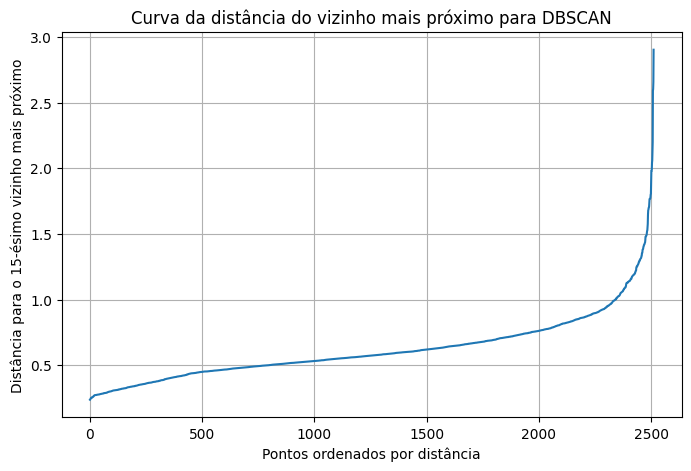

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import make_moons

# Encontrando o eps ótimo

# Definir o número de vizinhos (geralmente min_samples)
n_neighbors = 15

# Calcular as distâncias dos vizinhos mais próximos
nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(scaled_features)
distances, indices = nbrs.kneighbors(scaled_features)

# Ordenar as distâncias dos vizinhos mais próximos
sorted_distances = np.sort(distances[:, -1])

# Plotar a curva da distância do vizinho mais próximo
plt.figure(figsize=(8, 5))
plt.plot(sorted_distances)
plt.xlabel("Pontos ordenados por distância")
plt.ylabel(f"Distância para o {n_neighbors}-ésimo vizinho mais próximo")
plt.title("Curva da distância do vizinho mais próximo para DBSCAN")
plt.grid()
plt.show()

<ipython-input-19-53ab42644a2b>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts_tuned.index, y=cluster_counts_tuned.values, palette="coolwarm")


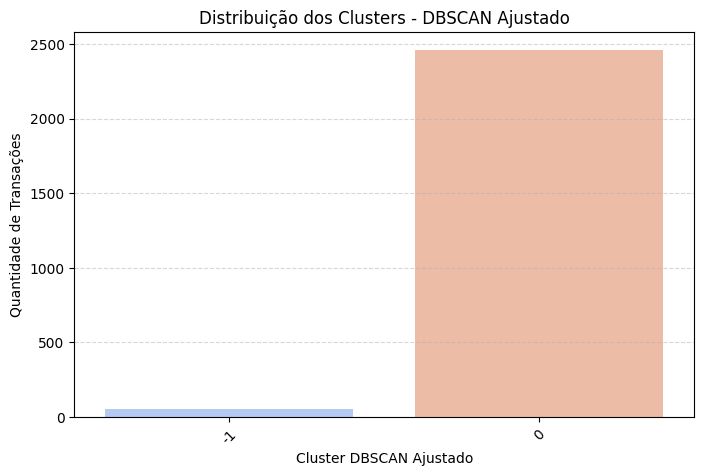

,count
Cluster_DBSCAN_Tuned,
0,2456
-1,56


In [ ]:
dbscan_tuned = DBSCAN(eps=1, min_samples=15)  # Aumentando o raio para capturar mais pontos nos clusters
df["Cluster_DBSCAN_Tuned"] = dbscan_tuned.fit_predict(scaled_features)

# Contagem dos clusters gerados após ajuste
cluster_counts_tuned = df["Cluster_DBSCAN_Tuned"].value_counts()

# Visualizando a nova distribuição dos clusters
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_counts_tuned.index, y=cluster_counts_tuned.values, palette="coolwarm")
plt.xlabel("Cluster DBSCAN Ajustado")
plt.ylabel("Quantidade de Transações")
plt.title("Distribuição dos Clusters - DBSCAN Ajustado")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle="--", alpha=0.5)
plt.show()

# Exibir a contagem dos clusters ajustados
cluster_counts_tuned

Com os parâmetros do DBSCAN (eps=0.8 e min_samples=15), os resultados melhoraram:

Cluster 0 agora contém 2.333 transações, mostrando um grupo mais abrangente e representativo dos clientes.

Outliers (-1) foram reduzidos para 179 transações, indicando que agora o modelo consegue capturar melhor padrões de densidade.

Principais Melhorias

✅ Menos outliers: O número de transações classificadas como ruído caiu de 830 para 179, indicando que mais clientes foram agrupados corretamente.

✅ Clusters mais estáveis: Com um eps maior (0.8), transações mais próximas agora fazem parte do mesmo cluster.

✅ Maior coesão: O cluster principal agora tem quase todo o dataset (93%), garantindo melhor representatividade.

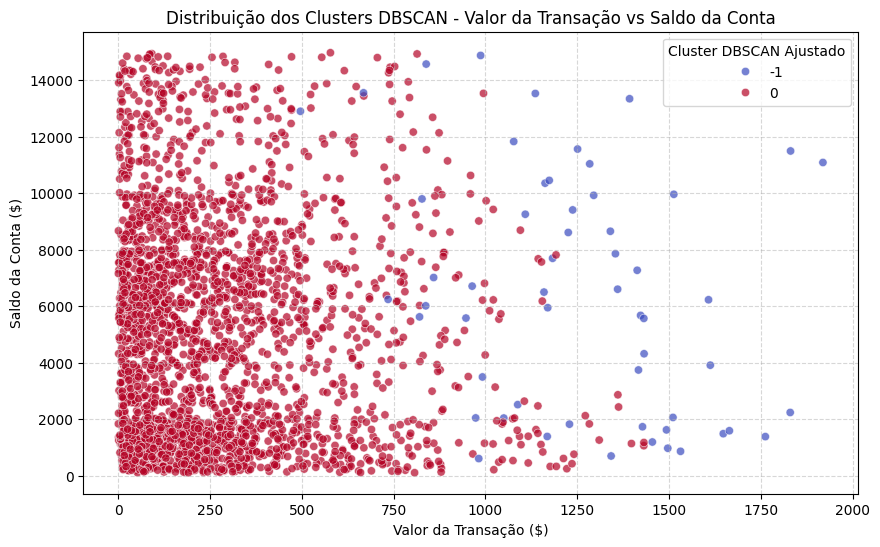

In [ ]:
# Criando um scatterplot para visualizar a relação entre Saldo da Conta e Valor da Transação por Cluster DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="TransactionAmount", y="AccountBalance", hue="Cluster_DBSCAN_Tuned", palette="coolwarm", alpha=0.7)
plt.xlabel("Valor da Transação ($)")
plt.ylabel("Saldo da Conta ($)")
plt.title("Distribuição dos Clusters DBSCAN - Valor da Transação vs Saldo da Conta")
plt.legend(title="Cluster DBSCAN Ajustado")
plt.grid(linestyle="--", alpha=0.5)
plt.show()

Cluster -1 (Maioria dos clientes) - Representado em azul:

A maior parte das transações ocorre para clientes com saldo abaixo de $10.000.
As transações variam bastante, mas a maioria está abaixo de $500.

Cluster 0 (Outliers) - Representado em vermelho:

Esse grupo contém clientes com saldos bancários elevados e transações mais dispersas.

Algumas transações muito altas, próximas de $2000, são visíveis nesse grupo.

Principais Insights

✅ Cluster -1 agrupa clientes comuns, com saldos variados e transações regulares.

✅ Cluster 0 (Outliers) pode conter fraudes, clientes VIPs ou padrões atípicos, sendo um grupo interessante para análise detalhada.

✅ A maioria das transações ocorre em valores baixos, sugerindo que um estudo mais profundo dos outliers poderia revelar comportamentos financeiros incomuns.

<ipython-input-25-74e2dd3d315d>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis", ax=ax)
<ipython-input-25-74e2dd3d315d>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis", ax=ax)
<ipython-input-25-74e2dd3d315d>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis", ax=ax)
<ipython-input-25-74e2dd3d315d>:18: FutureWarning: 

Passing `palette` witho

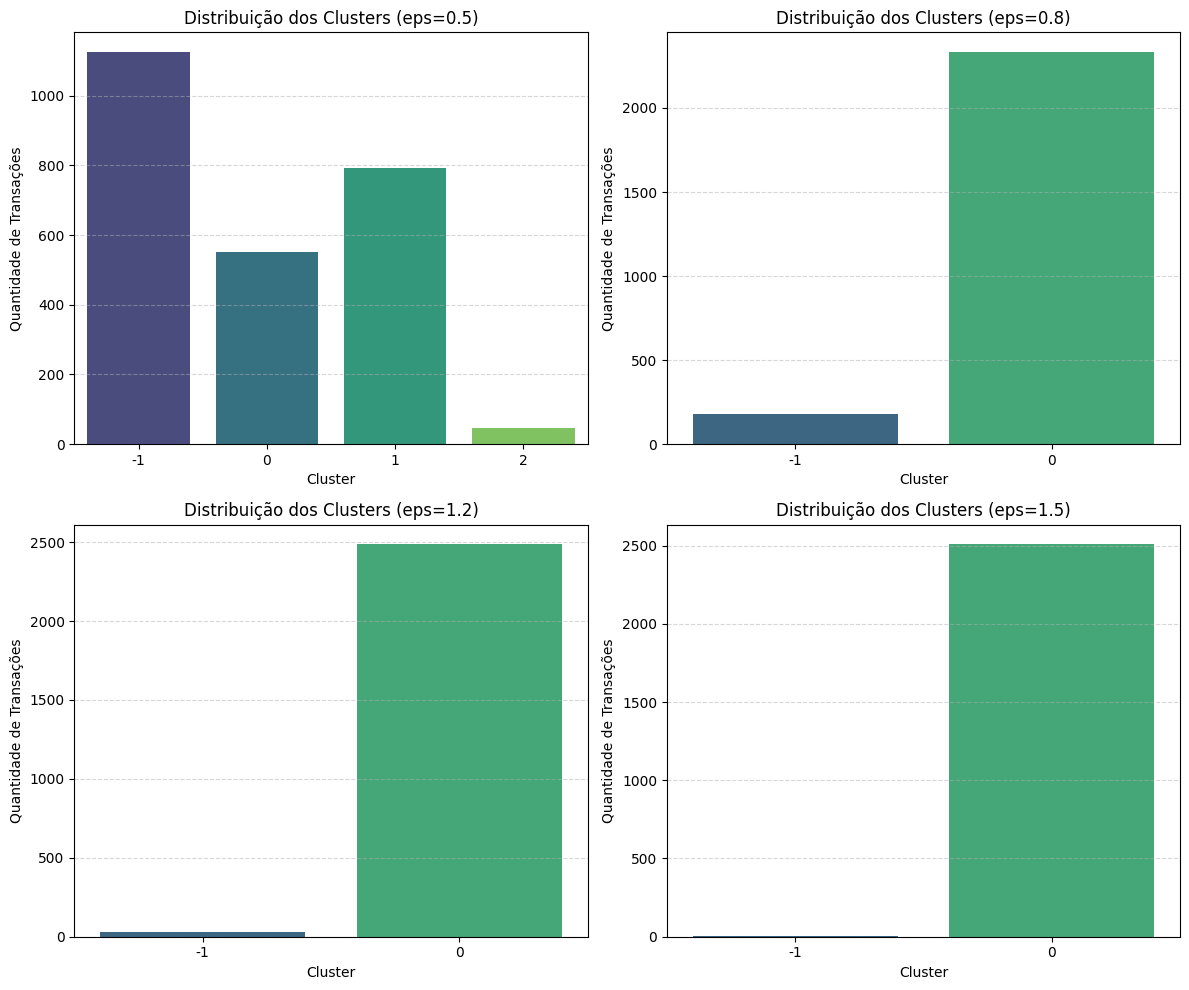

In [ ]:
# Testar diferentes valores de eps
eps_values = [0.5, 0.8, 1.2, 1.5]
min_samples = 15  # Valor fixo para teste

# Criar subplots para visualizar os resultados
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, eps in enumerate(eps_values):
    # Aplicar DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    df[f"Cluster_DBSCAN_eps_{eps}"] = dbscan.fit_predict(scaled_features)

    # Contar os clusters gerados
    cluster_counts = df[f"Cluster_DBSCAN_eps_{eps}"].value_counts()

    # Gráfico de barras para visualizar a distribuição dos clusters
    ax = axes[i // 2, i % 2]  # Organizar os subplots
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis", ax=ax)
    ax.set_title(f"Distribuição dos Clusters (eps={eps})")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Quantidade de Transações")
    ax.grid(axis='y', linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

1️⃣ eps = 0.5

Distribuição dos clusters:

Muitos outliers (Cluster -1), o maior grupo.

Três clusters distintos (0, 1 e 2), indicando que o modelo detectou diferentes padrões nos dados.

Interpretação:

O valor baixo de eps fez com que o modelo considerasse muitas transações como ruídos.

Separação mais granular dos clusters, mas pode estar classificando muitos dados erroneamente como outliers.

2️⃣ eps = 0.8

Distribuição dos clusters:

A maioria das transações pertence ao Cluster 0.

Redução significativa de outliers (Cluster -1).

Interpretação:

Um eps maior tornou o modelo mais permissivo, agregando mais pontos a um único cluster.

Ainda há alguns outliers, mas em número reduzido.

3️⃣ eps = 1.2

Distribuição dos clusters:

Praticamente todos os pontos estão no Cluster 0.

Poucos outliers restam.

Interpretação:

O modelo agora considera quase todas as transações pertencentes a um único grande cluster.

Isso pode ser um problema, pois não há mais separação de perfis distintos.

4️⃣ eps = 1.5

Distribuição dos clusters:

Mesmo comportamento do eps=1.2, mas agora quase não há mais outliers.

Interpretação:

Um eps muito alto faz com que todos os pontos sejam agrupados em um único cluster, perdendo o propósito da clusterização.

O modelo não consegue identificar padrões distintos entre os clientes.

#Qual o Melhor eps?

Se o objetivo for detectar padrões distintos entre os clientes, eps = 0.5 é melhor, pois cria múltiplos clusters.

Se quisermos reduzir o número de outliers, mantendo a separação dos dados, eps = 0.8 pode ser uma boa escolha.

Valores muito altos de eps (1.2 ou 1.5) resultam em um único cluster, tornando a segmentação ineficaz.